# Fourier Transform Spectra of Basic Trig Functions

This notebook shows the frequency spectrum of:

- $\sin(x)$
- $\\cos(x)$

We approximate the continuous Fourier transform using an FFT on a large, uniformly sampled interval.

Expected peak locations:

- $\\sin(x)$: peaks at $\\omega=\\pm 1$
- $\\cos(x)$: peaks at $\\omega=\\pm 1$

In [15]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams.update({'font.size': 12})

# Sampling setup: large interval to sharpen spectral peaks
L = 40 * np.pi
N = 2**14
x = np.linspace(-L, L, N, endpoint=False)
dx = x[1] - x[0]

# Angular-frequency grid corresponding to x-grid
omega = 2 * np.pi * np.fft.fftshift(np.fft.fftfreq(N, d=dx))

def fft_spectrum(fx):
    """Return shifted FFT magnitude as an approximation to |F(omega)|."""
    F = dx * np.fft.fftshift(np.fft.fft(fx))
    return np.abs(F)

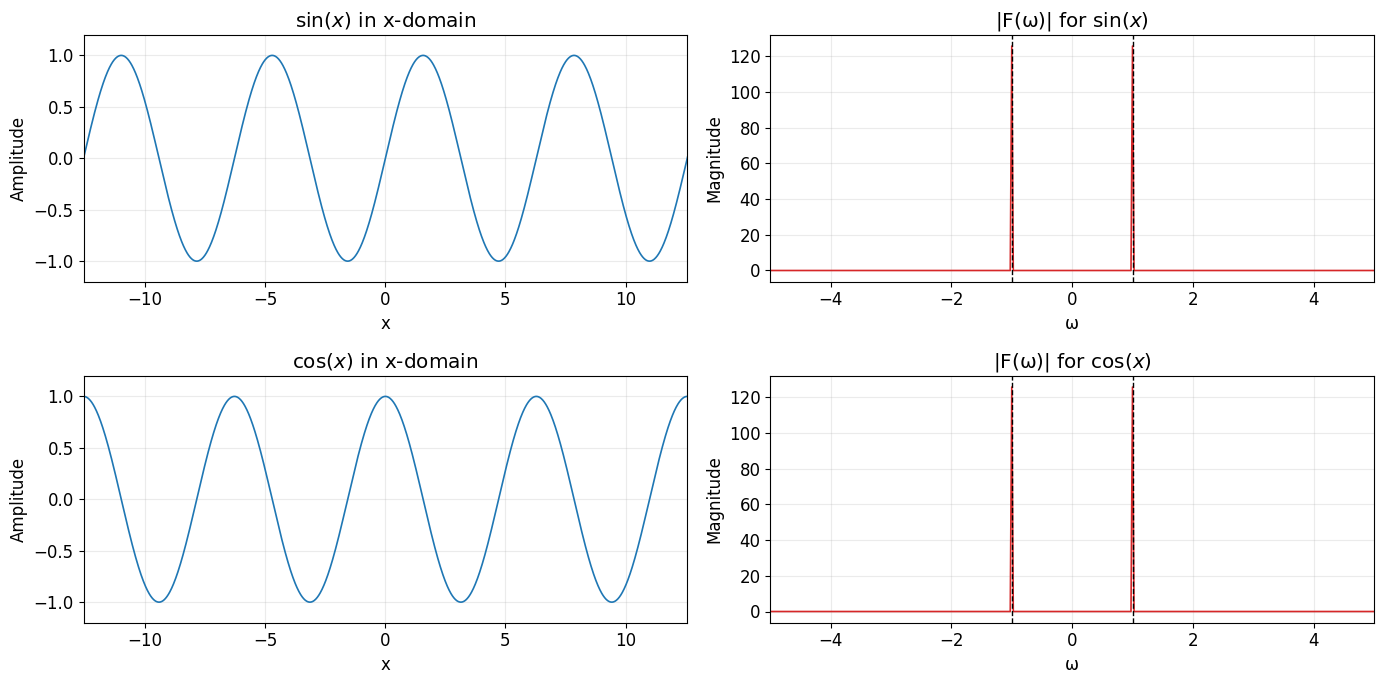

In [10]:
signals = [
    (r'$\sin(x)$', np.sin(x), [-1, 1]),
    (r'$\cos(x)$', np.cos(x), [-1, 1]),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 7))

for i, (name, fx, expected_peaks) in enumerate(signals):
    # Left panel: signal in time/domain x
    axes[i, 0].plot(x, fx, color='tab:blue', linewidth=1.2)
    axes[i, 0].set_xlim(-4 * np.pi, 4 * np.pi)
    axes[i, 0].set_ylim(-1.2, 1.2)
    axes[i, 0].grid(alpha=0.25)
    axes[i, 0].set_title(f'{name} in x-domain')
    axes[i, 0].set_xlabel('x')
    axes[i, 0].set_ylabel('Amplitude')

    # Right panel: magnitude spectrum
    mag = fft_spectrum(fx)
    axes[i, 1].plot(omega, mag, color='tab:red', linewidth=1.2)
    axes[i, 1].set_xlim(-5, 5)
    axes[i, 1].grid(alpha=0.25)
    axes[i, 1].set_title(f'|F(ω)| for {name}')
    axes[i, 1].set_xlabel('ω')
    axes[i, 1].set_ylabel('Magnitude')

    # Mark expected peak locations
    for w0 in expected_peaks:
        axes[i, 1].axvline(w0, color='black', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

## Complex Fourier Coefficients, Peak Height, and Units

The Fourier transform is complex:

$$
F(\omega)=\int f(x)e^{-i\omega x}\,dx = \operatorname{Re}F(\omega) + i\,\operatorname{Im}F(\omega).
$$

For real-valued signals, coefficients come in conjugate pairs:

$$
F(-\omega)=\overline{F(\omega)}.
$$

Why peak magnitude is around `120` in this notebook:

- We are transforming over a finite window `[-L, L]` with `L=40\pi`, so total length is `T = 2L = 80\pi \approx 251.33`.
- For a unit-amplitude pure sinusoid in this finite window, each main spectral line is about `T/2`.
- So expected peak size is about `T/2 \approx 125.66` (close to what you see, around `120+`, depending on grid alignment/leakage).

Units of magnitude:

- Because we compute `F` with `dx * FFT`, it approximates the integral above.
- Therefore, `F` has units of `(units of f) * (units of x)`.
- If `x` were in seconds and `f` were volts, `|F|` would be in volt-seconds.
- Here `x` is an abstract coordinate, so `|F|` is in "amplitude * x-units".

A normalized line height is `|F| / T`; for a unit sinusoid this is near `0.5` at each of `\pm\omega_0`.

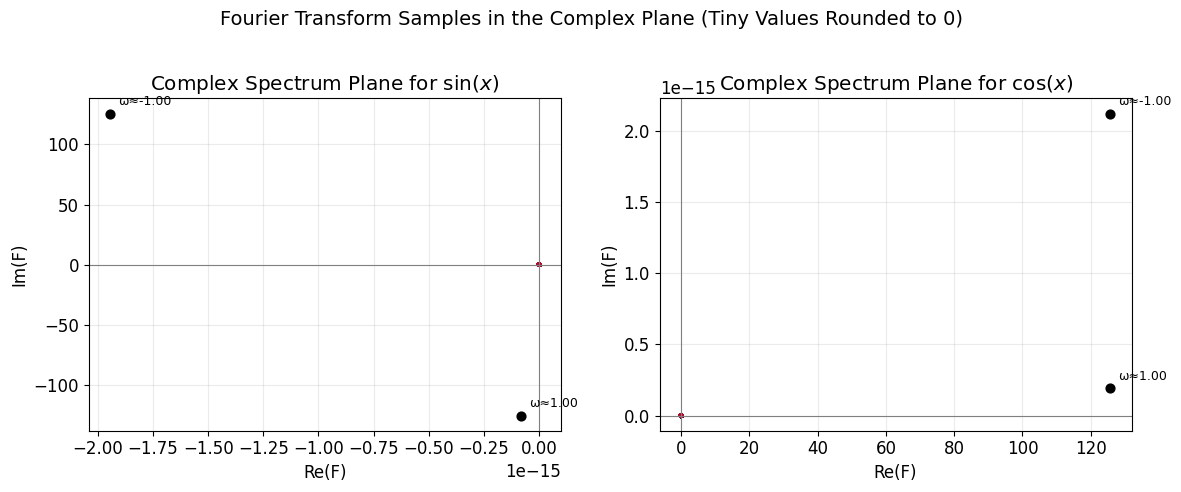

Total window length T = 251.32741
Expected main-line magnitude for unit sinusoid: T/2 = 125.66371

$\sin(x)$: threshold tol = 1.257e-08, nonzero bins after rounding = 2
  peak magnitudes near ±ω0 = [125.664, 125.664]
  average |F| ≈ 125.66371, normalized average |F|/T ≈ 0.50000

$\cos(x)$: threshold tol = 1.257e-08, nonzero bins after rounding = 2
  peak magnitudes near ±ω0 = [125.664, 125.664]
  average |F| ≈ 125.66371, normalized average |F|/T ≈ 0.50000

Conjugate symmetry check for sin(x):
  F(+1) ≈ -0.000000 + -125.663706j
  F(-1) ≈ -0.000000 + 125.663706j
  |F(-1) - conj(F(+1))| = 1.860e-15


In [11]:
def fft_complex(fx):
    # Complex-valued FT approximation using the same scaling as the notebook.
    return dx * np.fft.fftshift(np.fft.fft(fx))


def zero_small_complex(F, rel_tol=1e-10):
    """Zero-out tiny numerical noise relative to the peak magnitude."""
    peak = np.max(np.abs(F))
    tol = rel_tol * peak
    F_clean = F.copy()
    F_clean[np.abs(F_clean) < tol] = 0.0 + 0.0j
    return F_clean, tol


signals_complex = [
    (r'$\sin(x)$', np.sin(x), [-1, 1]),
    (r'$\cos(x)$', np.cos(x), [-1, 1]),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes = axes.ravel()

for i, (name, fx, peaks) in enumerate(signals_complex):
    F_raw = fft_complex(fx)
    F, tol = zero_small_complex(F_raw, rel_tol=1e-10)

    # Argand plot (complex plane): each frequency sample is one point.
    axes[i].scatter(F.real, F.imag, c=omega, s=6, cmap='coolwarm', alpha=0.7)
    axes[i].axhline(0, color='gray', linewidth=0.8)
    axes[i].axvline(0, color='gray', linewidth=0.8)

    # Highlight nearest bins to expected peak frequencies.
    for w0 in peaks:
        idx = np.argmin(np.abs(omega - w0))
        axes[i].scatter(F.real[idx], F.imag[idx], color='black', s=40)
        axes[i].annotate(
            f'ω≈{omega[idx]:.2f}',
            (F.real[idx], F.imag[idx]),
            textcoords='offset points',
            xytext=(6, 6),
            fontsize=9,
        )

    axes[i].set_title(f'Complex Spectrum Plane for {name}')
    axes[i].set_xlabel('Re(F)')
    axes[i].set_ylabel('Im(F)')
    axes[i].grid(alpha=0.25)

fig.suptitle('Fourier Transform Samples in the Complex Plane (Tiny Values Rounded to 0)', fontsize=14)
plt.tight_layout()
plt.show()

# Quantify the peak heights and normalized values.
T = 2 * L
print(f'Total window length T = {T:.5f}')
print(f'Expected main-line magnitude for unit sinusoid: T/2 = {T/2:.5f}\n')

for name, fx, peaks in signals_complex:
    F_raw = fft_complex(fx)
    F, tol = zero_small_complex(F_raw, rel_tol=1e-10)

    mags = []
    for w0 in peaks:
        idx = np.argmin(np.abs(omega - w0))
        mags.append(np.abs(F[idx]))

    avg_mag = np.mean(mags)
    nnz = np.count_nonzero(F)
    print(f'{name}: threshold tol = {tol:.3e}, nonzero bins after rounding = {nnz}')
    print(f'  peak magnitudes near ±ω0 = {[round(float(m), 3) for m in mags]}')
    print(f'  average |F| ≈ {avg_mag:.5f}, normalized average |F|/T ≈ {avg_mag/T:.5f}\n')

# Explicit conjugate-pair check for sin(x): F(-ω) = conjugate(F(ω))
Fsin_raw = fft_complex(np.sin(x))
Fsin, _ = zero_small_complex(Fsin_raw, rel_tol=1e-10)
idx_p = np.argmin(np.abs(omega - 1.0))
idx_m = np.argmin(np.abs(omega + 1.0))

Fp = Fsin[idx_p]
Fm = Fsin[idx_m]
conj_err = np.abs(Fm - np.conj(Fp))

print('Conjugate symmetry check for sin(x):')
print(f'  F(+1) ≈ {Fp.real:.6f} + {Fp.imag:.6f}j')
print(f'  F(-1) ≈ {Fm.real:.6f} + {Fm.imag:.6f}j')
print(f'  |F(-1) - conj(F(+1))| = {conj_err:.3e}')

## Fourier Coefficients $c_k$

The Fourier series coefficients on $[-L, L]$ are related to the FT by:

$$
c_k = \frac{F(\omega_k)}{2L} = \frac{F(\omega_k)}{T}, \qquad \omega_k = \frac{k\pi}{L}.
$$

For a unit sinusoid the two nonzero $c_k$ values each have magnitude $T/2 \div T = 0.5$.

- $\sin(\omega_0 x) = \frac{1}{2i}e^{+i\omega_0 x} - \frac{1}{2i}e^{-i\omega_0 x}$: coefficients are $c_{+} = -i/2$, $c_{-} = +i/2$.
- $\cos(\omega_0 x) = \frac{1}{2}e^{+i\omega_0 x} + \frac{1}{2}e^{-i\omega_0 x}$: coefficients are $c_{+} = c_{-} = 1/2$.

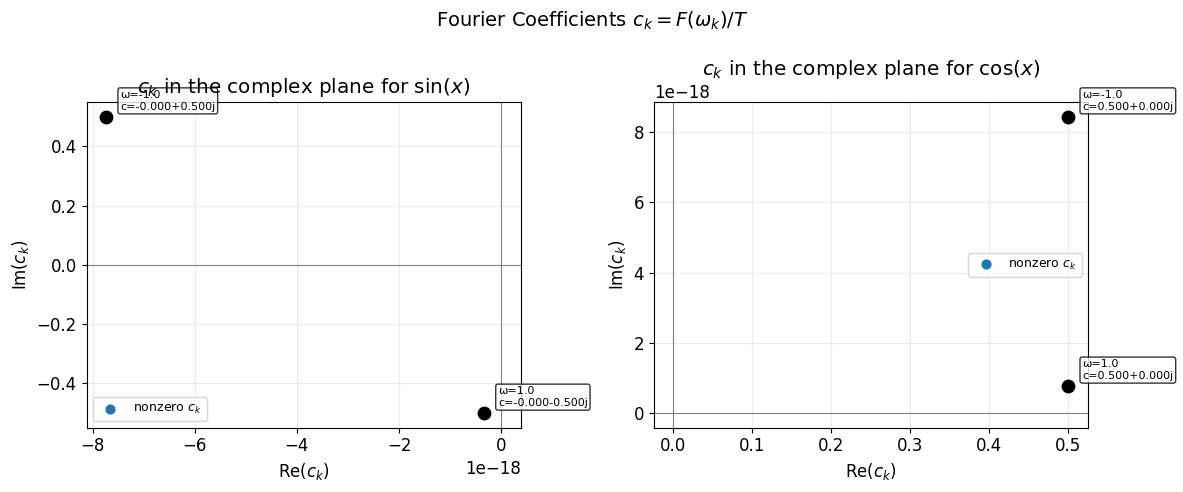

Signal             ω_k       Re(c_k)       Im(c_k)       |c_k|
--------------------------------------------------------------
$\sin(x)$       -1.000     -0.000000      0.500000    0.500000
$\sin(x)$        1.000     -0.000000     -0.500000    0.500000
$\cos(x)$       -1.000      0.500000      0.000000    0.500000
$\cos(x)$        1.000      0.500000      0.000000    0.500000


In [14]:
T = 2 * L   # total window length

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes = axes.ravel()

for i, (name, fx, peaks) in enumerate(signals_complex):
    F_raw = fft_complex(fx)
    F_clean, _ = zero_small_complex(F_raw, rel_tol=1e-10)

    # Fourier series coefficients: c_k = F(omega_k) / T
    ck = F_clean / T

    # ── Argand (complex plane) plot of all c_k ──────────────────────────────
    # Only plot the nonzero ones so the axis scale is meaningful
    nonzero_mask = np.abs(ck) > 0
    axes[i].scatter(ck[nonzero_mask].real, ck[nonzero_mask].imag,
                    color='tab:blue', s=40, zorder=3, label='nonzero $c_k$')
    axes[i].axhline(0, color='gray', linewidth=0.8)
    axes[i].axvline(0, color='gray', linewidth=0.8)

    # Annotate each nonzero coefficient
    for w0 in peaks:
        idx = np.argmin(np.abs(omega - w0))
        c = ck[idx]
        axes[i].scatter(c.real, c.imag, color='black', s=80, zorder=4)
        axes[i].annotate(
            f'ω={omega[idx]:.1f}\nc={c.real:.3f}{c.imag:+.3f}j',
            (c.real, c.imag),
            textcoords='offset points',
            xytext=(10, 5),
            fontsize=8,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8),
        )

    axes[i].set_title(f'$c_k$ in the complex plane for {name}')
    axes[i].set_xlabel('Re($c_k$)')
    axes[i].set_ylabel('Im($c_k$)')
    axes[i].grid(alpha=0.25)
    axes[i].legend(fontsize=9)

fig.suptitle('Fourier Coefficients $c_k = F(\\omega_k)/T$', fontsize=14)
plt.tight_layout()
plt.show()

# ── Print table of nonzero c_k ────────────────────────────────────────────
print(f"{'Signal':<14}  {'ω_k':>6}  {'Re(c_k)':>12}  {'Im(c_k)':>12}  {'|c_k|':>10}")
print('-' * 62)
for name, fx, peaks in signals_complex:
    F_raw = fft_complex(fx)
    F_clean, _ = zero_small_complex(F_raw, rel_tol=1e-10)
    ck = F_clean / T
    for w0 in peaks:
        idx = np.argmin(np.abs(omega - w0))
        c = ck[idx]
        print(f"{name:<14}  {omega[idx]:>6.3f}  {c.real:>12.6f}  {c.imag:>12.6f}  {abs(c):>10.6f}")

## Spectrum of the Dirac Delta $\delta(x)$

The continuous Fourier transform of a Dirac delta is:

$$
F(\omega) = \int_{-\infty}^{\infty} \delta(x)\, e^{-i\omega x}\, dx = 1 \quad \text{for all } \omega.
$$

**The spectrum is perfectly flat** — all frequencies are present with equal magnitude 1. This is the defining property of an impulse: it contains every frequency simultaneously.

In practice we approximate $\delta(x)$ with a narrow Gaussian:

$$
\delta_\sigma(x) = \frac{1}{\sigma\sqrt{2\pi}} e^{-x^2 / (2\sigma^2)}, \qquad \sigma \to 0.
$$

Its FT is $e^{-\sigma^2\omega^2/2}$, which approaches 1 for small $\sigma$. The narrower the pulse, the broader (flatter) the spectrum — a direct expression of the **time–bandwidth uncertainty principle**.

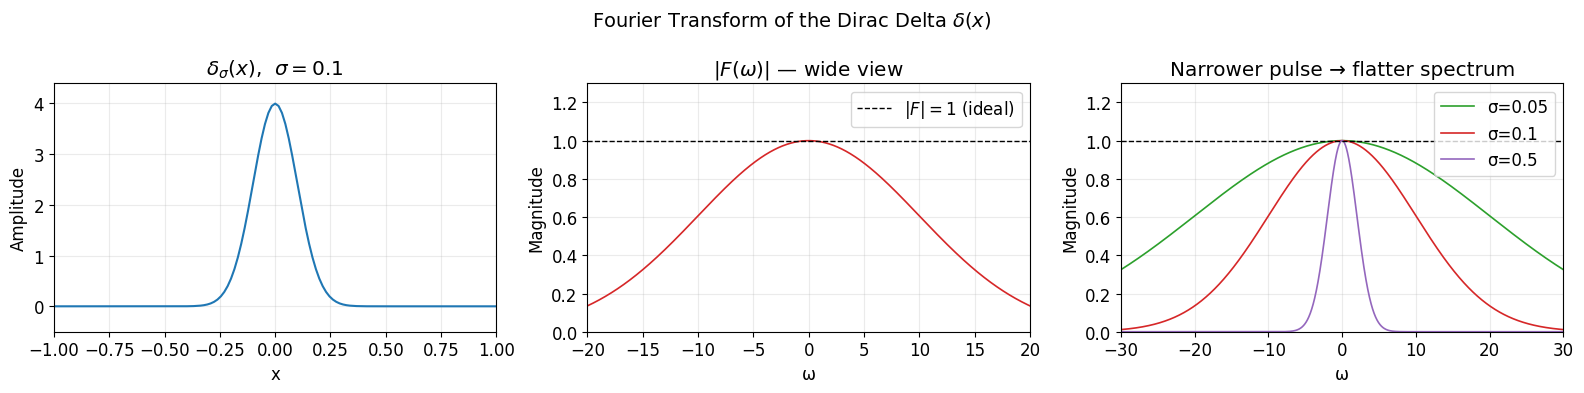

Mean |F(ω)| for |ω| < 5:  0.95966  (ideal: 1.0)
Std  |F(ω)| for |ω| < 5:  3.55e-02


In [16]:
# Approximate δ(x) as a narrow Gaussian centered at x=0
sigma = 0.1   # width — try making this smaller/larger to see the effect
delta_approx = np.exp(-x**2 / (2 * sigma**2)) / (sigma * np.sqrt(2 * np.pi))

# FT magnitude
F_delta = fft_spectrum(delta_approx)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ── Panel 1: the delta approximation in x-domain ──────────────────────────
axes[0].plot(x, delta_approx, color='tab:blue', linewidth=1.5)
axes[0].set_xlim(-1, 1)
axes[0].set_ylim(-0.5, delta_approx.max() * 1.1)
axes[0].set_title(f'$\\delta_\\sigma(x)$,  $\\sigma={sigma}$')
axes[0].set_xlabel('x')
axes[0].set_ylabel('Amplitude')
axes[0].grid(alpha=0.25)

# ── Panel 2: magnitude spectrum (wide view) ────────────────────────────────
axes[1].plot(omega, F_delta, color='tab:red', linewidth=1.2)
axes[1].axhline(1.0, color='black', linestyle='--', linewidth=1, label='$|F|=1$ (ideal)')
axes[1].set_xlim(-20, 20)
axes[1].set_ylim(0, 1.3)
axes[1].set_title('$|F(\\omega)|$ — wide view')
axes[1].set_xlabel('ω')
axes[1].set_ylabel('Magnitude')
axes[1].legend()
axes[1].grid(alpha=0.25)

# ── Panel 3: compare different σ values ───────────────────────────────────
for s, col in [(0.05, 'tab:green'), (0.1, 'tab:red'), (0.5, 'tab:purple')]:
    d = np.exp(-x**2 / (2 * s**2)) / (s * np.sqrt(2 * np.pi))
    axes[2].plot(omega, fft_spectrum(d), color=col, linewidth=1.2, label=f'σ={s}')
axes[2].axhline(1.0, color='black', linestyle='--', linewidth=1)
axes[2].set_xlim(-30, 30)
axes[2].set_ylim(0, 1.3)
axes[2].set_title('Narrower pulse → flatter spectrum')
axes[2].set_xlabel('ω')
axes[2].set_ylabel('Magnitude')
axes[2].legend()
axes[2].grid(alpha=0.25)

plt.suptitle('Fourier Transform of the Dirac Delta $\\delta(x)$', fontsize=14)
plt.tight_layout()
plt.show()

# Print the flat-band magnitude
flat_band = np.abs(omega) < 5
print(f'Mean |F(ω)| for |ω| < 5:  {F_delta[flat_band].mean():.5f}  (ideal: 1.0)')
print(f'Std  |F(ω)| for |ω| < 5:  {F_delta[flat_band].std():.2e}')

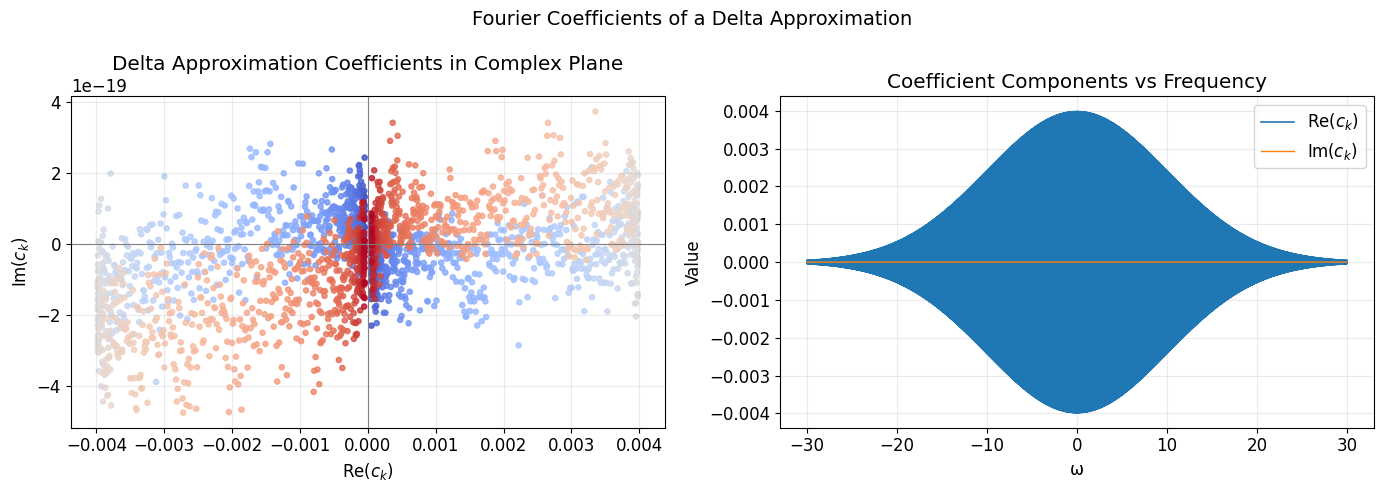

Noise threshold used: 3.979e-15
Mean Re(c_k) for |ω|<=5: 0.000009
Max |Im(c_k)| for |ω|<=30: 4.743e-19


In [17]:
# Fourier coefficients for the delta approximation on the complex plane
# Using the same normalization as above: c_k = F(omega_k) / T
F_delta_complex = fft_complex(delta_approx)
c_delta = F_delta_complex / T

# Clean tiny floating-point noise so the geometry is clearer
c_delta_clean, tol_delta = zero_small_complex(c_delta, rel_tol=1e-12)

# Focus on a finite frequency window for readability
mask = np.abs(omega) <= 30
w_plot = omega[mask]
c_plot = c_delta_clean[mask]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: all selected coefficients in the complex plane
axes[0].scatter(c_plot.real, c_plot.imag, c=w_plot, cmap='coolwarm', s=14, alpha=0.8)
axes[0].axhline(0, color='gray', linewidth=0.8)
axes[0].axvline(0, color='gray', linewidth=0.8)
axes[0].set_title('Delta Approximation Coefficients in Complex Plane')
axes[0].set_xlabel('Re($c_k$)')
axes[0].set_ylabel('Im($c_k$)')
axes[0].grid(alpha=0.25)

# Right: real-vs-frequency to show near-flat magnitude around zero frequency
axes[1].plot(w_plot, c_plot.real, color='tab:blue', linewidth=1.2, label='Re($c_k$)')
axes[1].plot(w_plot, c_plot.imag, color='tab:orange', linewidth=1.0, label='Im($c_k$)')
axes[1].set_title('Coefficient Components vs Frequency')
axes[1].set_xlabel('ω')
axes[1].set_ylabel('Value')
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.suptitle('Fourier Coefficients of a Delta Approximation', fontsize=14)
plt.tight_layout()
plt.show()

print(f'Noise threshold used: {tol_delta:.3e}')
print(f'Mean Re(c_k) for |ω|<=5: {c_delta_clean[np.abs(omega)<=5].real.mean():.6f}')
print(f'Max |Im(c_k)| for |ω|<=30: {np.max(np.abs(c_plot.imag)):.3e}')

## Why Does the Inverse FT Use $e^{+i\omega x}$ (and Not $e^{-i\omega x}$)?

Both sign choices are valid. The sign is a **convention**, but the forward and inverse transforms must use opposite signs.

A common convention is:

$$
F(\omega)=\int_{-\infty}^{\infty} f(x)e^{-i\omega x}\,dx,
\qquad
f(x)=\frac{1}{2\pi}\int_{-\infty}^{\infty} F(\omega)e^{+i\omega x}\,d\omega.
$$

An equally valid alternative is:

$$
F(\omega)=\int_{-\infty}^{\infty} f(x)e^{+i\omega x}\,dx,
\qquad
f(x)=\frac{1}{2\pi}\int_{-\infty}^{\infty} F(\omega)e^{-i\omega x}\,d\omega.
$$

So changing the sign in one formula is fine, as long as you change the inverse accordingly.

### Is the transform symmetric about the y-axis?

Not in general.

- In general, $F(\omega)$ is not an even function.
- If $f(x)$ is real-valued, then:
  $$F(-\omega)=\overline{F(\omega)}$$
  (conjugate symmetry).
- If $f(x)$ is real and even, then $F(\omega)$ is real and even.
- If $f(x)$ is real and odd, then $F(\omega)$ is imaginary and odd.

So y-axis symmetry appears only for special classes of signals (such as real-even signals), not for all signals.

## Unitary Transform

A **unitary transform** is a linear transform that preserves inner products, norms, and angles.

For a matrix/operator $U$:

$$
U^*U = UU^* = I,
$$

where $U^*$ is the conjugate transpose. This implies:

- $\lVert Ux \rVert_2 = \lVert x \rVert_2$ (energy is preserved)
- $\langle Ux, Uy \rangle = \langle x, y \rangle$ (inner products are preserved)
- $U^{-1} = U^*$

So a unitary transform changes coordinates without stretching or shrinking the vector space.

### Fourier Transform and Unitarity

The Fourier transform can be written in a unitary form by using symmetric normalization factors.

- Continuous FT: use $\tfrac{1}{\sqrt{2\pi}}$ in both forward and inverse transforms.
- Discrete FT (length $N$): use $\tfrac{1}{\sqrt{N}}$ scaling.

With this normalization, Parseval/Plancherel is exact: total energy in time/domain equals total energy in frequency domain.